# Unsupervised Learning Modeling

In supervised learning notebook, we told models: “Here are the fraud cases, learn to recognize them.” Models used the class labels to train themselves.

Unsupervised learning asks a different question: “Without looking at the labels, do the fraud cases naturally form distinct clusters?”

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Data

In [2]:
# Load preprocessed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Work on the full dataset for unsupervised
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(f"X_full: {X_full.shape} | Fraud count: {y_full.sum()}")

X_full: (284807, 30) | Fraud count: 492


## 2. Dimensionality Reduction with PCA

In [3]:
# Reduction to 2 dimensions to plot clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full)

print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained by PC1 + PC2: 21.74%


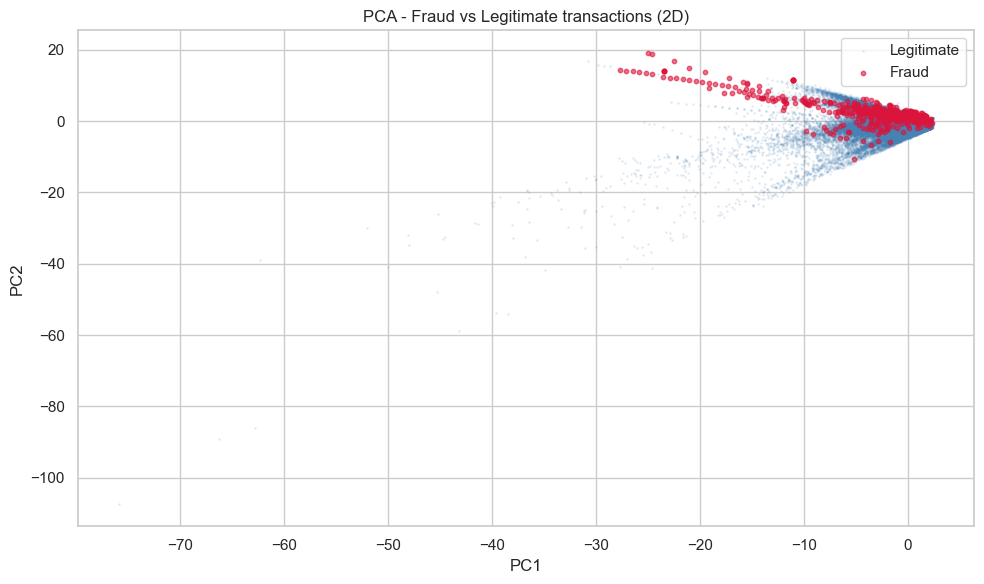

In [4]:
# Quick visualization: fraud vs legitimate in 2D
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_pca[y_full == 0, 0], X_pca[y_full == 0, 1],
           alpha=0.1, s=1, color='steelblue', label='Legitimate')
ax.scatter(X_pca[y_full == 1, 0], X_pca[y_full == 1, 1],
           alpha=0.6, s=10, color='crimson', label='Fraud')

ax.set_title('PCA - Fraud vs Legitimate transactions (2D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

### PCA Observations

- PC1 + PC2 explain only **21.74%** of total variance, which is expected with 30 PCA features.

- Despite low 2D coverage, fraud transactions already show **spatial separation** from legitimate ones (concentrated between PC1=-30 and PC1=+5, and PCA2=-10 and PCA2=20).
- The true separation in 30D space is likely even stronger, this confirms that fraud patterns are structurally distinct.

K-Means should be able to identify clusters that concentrate fraud.

## 3. K-Means Clustering

K-Means will group the 284,807 transactions into clusters based solely on the features, without ever seeing the Class label.

The question is: **Are fraudulent transactions concentrated in certain clusters?**

If so, this confirms that fraud patterns are structurally different from legitimate transactions, not just statistically. This provides independent validation of what we found in the supervised model.

In production, this could also be used to detect new types of fraud never seen during training: a new cluster appearing = a new suspicious pattern.

In [5]:
# Train K-Means on full dataset (no labels)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_full)

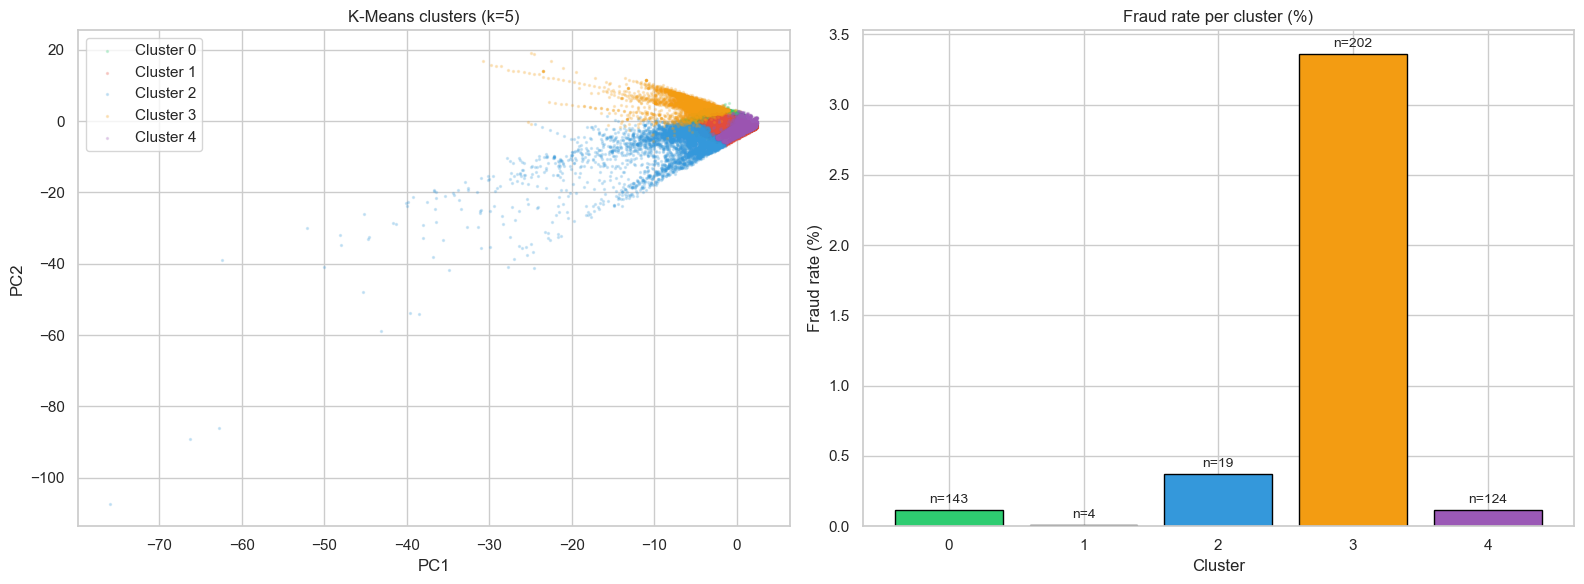

         sum   count    mean
cluster                     
0        143  124211  0.0012
1          4   42824  0.0001
2         19    5135  0.0037
3        202    6013  0.0336
4        124  106624  0.0012


In [6]:
# Visualize clusters in 2D PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: clusters
colors_clusters = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
for i in range(5):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.2, s=2, color=colors_clusters[i], label=f'Cluster {i}')
axes[0].set_title('K-Means clusters (k=5)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot 2: fraud concentration per cluster
cluster_fraud = pd.DataFrame({'cluster': clusters, 'fraud': y_full})
fraud_rate = cluster_fraud.groupby('cluster')['fraud'].mean() * 100
fraud_count = cluster_fraud.groupby('cluster')['fraud'].sum()

bars = axes[1].bar(fraud_rate.index, fraud_rate.values,
                   color=colors_clusters, edgecolor='black')
axes[1].set_title('Fraud rate per cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Fraud rate (%)')

# Add fraud count on each bar
for bar, count in zip(bars, fraud_count):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'n={count}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(cluster_fraud.groupby('cluster')['fraud'].agg(['sum', 'count', 'mean']).round(4))

### K-Means - Key observations

| Cluster | Transactions | Frauds | Fraud rate |
|---|---|---|---|
| 0 | 124,211 | 143 | 0.12% |
| 1 | 42,824 | 4 | 0.01% |
| 2 | 5,135 | 19 | 0.37% |
| **3** | **6,013** | **202** | **3.36%** |
| 4 | 106,624 | 124 | 0.12% |

**Cluster 3 concentrates 41% of all frauds (202/492) with a fraud rate 20x the global average.**

Without using any labels, K-Means naturally isolated a high-risk transaction segment.

This confirms that fraud patterns are structurally distinct from legitimate transactions, and it's consistent with PCA visualization and EDA correlation findings.

In production, Cluster 3 membership could serve as an additional risk signal.

## 4. DBSCAN - Anomaly Detection

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies:
- **Dense regions** → clusters
- **Isolated points** → outliers (label = -1)

Key intuition: a fraudulent transaction is "different" from all others.

If fraud patterns are truly anomalous, DBSCAN should flag them as outliers (anomalies).

The question is: **Do the outliers detected by DBSCAN correspond to actual fraud?**

This is an unsupervised anomaly detection approach, useful when labels are unavailable, which is often the case in real-world production environments.

No need to specify the number of clusters, DBSCAN finds them automatically.

Two parameters to tune:
- `eps` → maximum distance between two points to be considered neighbors
- `min_samples` → minimum points to form a dense region

In [7]:
# Sample 10k points (keep all frauds + random legitimate)
fraud_idx = y_full[y_full == 1].index
legit_idx = y_full[y_full == 0].sample(n=10000, random_state=42).index
sample_idx = fraud_idx.union(legit_idx)

X_pca_sample = X_pca[sample_idx]
y_sample = y_full[sample_idx].reset_index(drop=True)

print(f"Sample size: {len(sample_idx)} | Frauds: {y_sample.sum()}")

Sample size: 10492 | Frauds: 492


In [8]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca_sample)

In [11]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = (dbscan_labels == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outliers detected: {n_outliers} ({n_outliers/len(dbscan_labels)*100:.2f}%)")

Clusters found: 13
Outliers detected: 220 (2.10%)


Is fraud       0    1
Is outlier           
False       9867  405
True         133   87


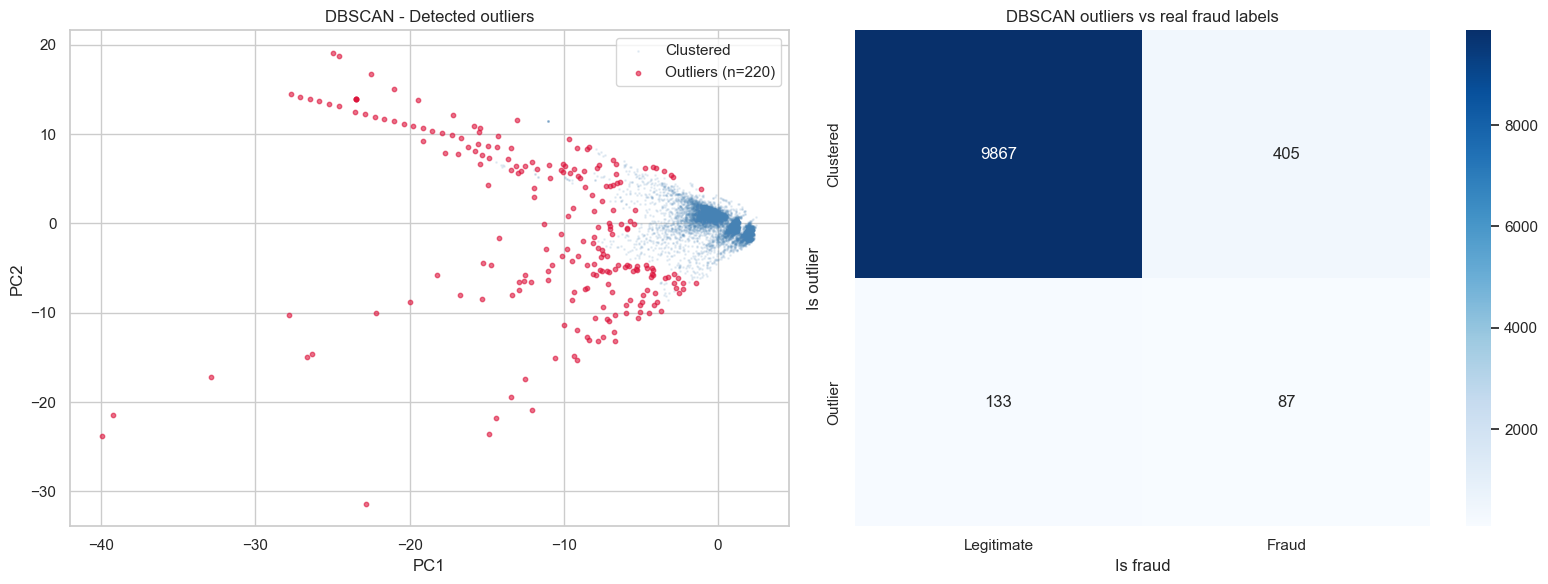


DBSCAN as fraud detector:
Precision : 0.395
Recall    : 0.177


In [12]:
# Clusters visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DBSCAN outliers
mask_outlier = dbscan_labels == -1
mask_cluster = dbscan_labels != -1

axes[0].scatter(X_pca_sample[mask_cluster, 0], X_pca_sample[mask_cluster, 1],
                alpha=0.1, s=1, color='steelblue', label='Clustered')
axes[0].scatter(X_pca_sample[mask_outlier, 0], X_pca_sample[mask_outlier, 1],
                alpha=0.6, s=10, color='crimson', label=f'Outliers (n={n_outliers})')
axes[0].set_title('DBSCAN - Detected outliers')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot 2: Do outliers match real frauds ?
outlier_fraud = pd.DataFrame({'outlier': mask_outlier, 'fraud': y_sample.values})
crosstab = pd.crosstab(outlier_fraud['outlier'], outlier_fraud['fraud'],
                       rownames=['Is outlier'], colnames=['Is fraud'])
print(crosstab)

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Clustered', 'Outlier'])
axes[1].set_title('DBSCAN outliers vs real fraud labels')

plt.tight_layout()
plt.show()

# Precision and Recall of DBSCAN as a fraud detector
tp = crosstab.loc[True, 1]
fp = crosstab.loc[True, 0]
fn = crosstab.loc[False, 1]

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(f"\nDBSCAN as fraud detector:")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")

### DBSCAN - Results

| Metric | Value |
|---|---|
| Outliers detected | 220 / 10,492 (2.1%) |
| True frauds among outliers | 87 |
| Precision | 0.395 |
| Recall | 0.177 |

**Note:** DBSCAN was run on a 10,492-point sample (all 492 frauds + 10,000 random legitimate transactions) due to O(n²) memory complexity on the full dataset.

**Interpretation:**
- DBSCAN captures the most extreme fraud patterns (visually isolated in PCA space) but misses subtle frauds that blend in with legitimate transactions.
- Modest performance is expected, DBSCAN uses no labels and works on a 2D projection, retaining only 21.74% of total variance.

Compared to supervised models, unsupervised anomaly detection is weaker but useful in production when no labeled data is available.